In [1]:
#Task 1: Implementation of MCP neurons

In [3]:
def mcp_and(x1,x2):
  w1,w2=1,1
  threshold=2
  summation=(w1 * x1) + (w2 * x2)
  if summation >= threshold :
    return 1
  else:
    return 0

inputs =[(0,0),(0,1),(1,0),(1,1)]
for x1, x2 in inputs:
  print(x1,x2, "->", mcp_and(x1,x2));


0 0 -> 0
0 1 -> 0
1 0 -> 0
1 1 -> 1


In [7]:
def mcp_or(x1,x2):
  w1,w2= 1, 1
  threshold=1
  summation=(x1*w1)+(x2*w2)
  if summation >= threshold:
    return 1
  else:
    return 0

inputs=[(0,0),(0,1),(1,0),(1,1)]
for x1,x2 in inputs:
    print(x1,x2, "=", mcp_or(x1,x2));

0 0 = 0
0 1 = 1
1 0 = 1
1 1 = 1


1. limiatations of mcp neuron:
   - fixed weights(manually assigned)
   - take binary inputs and outputs only
   - uses step function
   - cannot solve non-linear problems

2. Question - 2: Think if you can develop a logic to solve for XOR function using MCP Neuron.

- not possible with single neuron because XOR is non-linear separable and mcp neuron is a linear model.

In [ ]:
#Task 2: Perceptron Algorithm for 0 vs 1 Classification.

In [2]:
import pandas as pd

df_1 = pd.read_csv("/content/drive/MyDrive/Ai workshop 1/mnist_0_and_1.csv")

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
X = df_1.drop(columns=["label"]).values
Y = df_1["label"].values
print("Feature matrix shape:", X.shape)
print("Label vector shape:", Y.shape)

Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


X contains all input images, each flattened into a feature vector.
y contains the class label for each image in X.

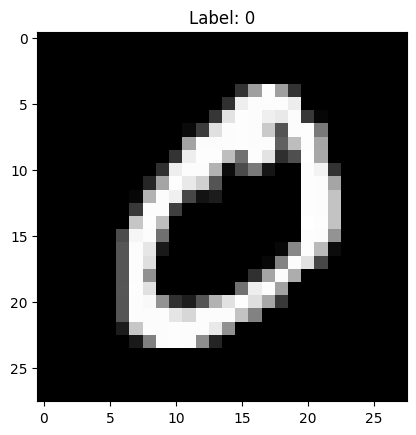

In [7]:
import numpy as np
import matplotlib.pyplot as plt


# Visualize first image
plt.imshow(X[0].reshape(28,28), cmap='gray')
plt.title(f"Label: {Y[0]}")
plt.show()

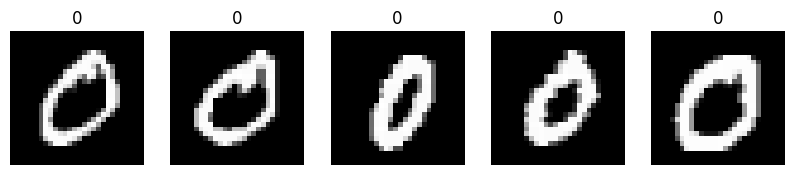

In [9]:
# Separate images for label 0 and label 1
images_0 = X[Y == 0] # Get all images with label 0
images_1 = X[Y == 1] # Get all images with label 1

# Show first 5 images of label 0
fig, axes = plt.subplots(1, 5, figsize=(10,2))
for i in range(5):
    axes[i].imshow(images_0[i].reshape(28,28), cmap='gray')
    axes[i].set_title("0")
    axes[i].axis('off')
plt.show()

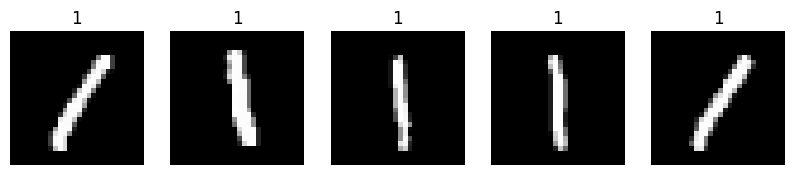

In [12]:
# Show first 5 images of label 1
fig, axes = plt.subplots(1, 5, figsize=(10,2))
for i in range(5):
    axes[i].imshow(images_1[i].reshape(28,28), cmap='gray')
    axes[i].set_title("1")
    axes[i].axis('off')
plt.show()

In [17]:
# Initialize weights and bias
weights = np.zeros(X.shape[1]) # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

Weight is 1D array of 784 numbers. each elements corresponds to one pizel in the image.

We initialize weights to zero so the perceptron starts neutral with no bias toward any output; during training, the weights are updated based on errors to learn which pixels are important for classification.

In [18]:
#4. Implement a Decision Function or Activation Function:
def activation_func(z):
  return 1 if z>=0 else 0

z= np.dot(X[i], weights) + bias
y_pred = activation_func(z)


In [19]:
#5. Implement the Perceptron Learning Algorithm:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):

    """
    TraintheperceptronusingthePerceptronLearningAlgorithm.
    Parameters:-X:Features(inputdata)asanumpyarrayofshape(n_samples,n_features)-y:Labels(trueoutput)asanumpyarrayofshape(n_samples,)-weights:Initialweightsasanumpyarrayofshape(n_features,)-bias:Initialbiasvalue(scalar)-learning_rate:Learningrateforweightupdates(defaultis0.1)-epochs:Numberofiterationstotrainthemodel(defaultis100)
    Returns:-weights:Updatedweightsaftertraining-bias:Updatedbiasaftertraining-accuracy:Totalcorrectprediction.
    """
# Step3:PerceptronLearningAlgorithm
# YourCodehere

    for epoch in range(epochs):
        correct = 0

        for i in range(len(X)):
            output = np.dot(X[i], weights) + bias

            # Prediction using step function
            y_hat = 1 if output >= 0 else 0

            # If prediction is correct
            if y_hat == y[i]:
                correct += 1
            else:
                # Update weights and bias
                weights = weights + learning_rate * (y[i] - y_hat) * X[i]
                bias = bias + learning_rate * (y[i] - y_hat)

        # Accuracy per epoch (optional)
        accuracy = correct / len(X)
        return weights, bias, accuracy

Question - 5: What is the purpose of the output = np.dot(X[i], weights) + bias line?

= It computed the weighted sum of inputs which is z that determines the decision boundary used to make prediction.

Question - 6: What happens when the prediction is wrong? How are the weights and
bias updated?
= When the prediction is wrong we update the weight and bias to reduce error.  Formula for weight update = w + learning_rate(y-y_hat)*x
formula for bias_update = b+learning_rate(y-y_hat)

Question - 7:Why is the final accuracy important, and what do you expect it to be?
- it measures the model performance  and how well model learned from data. Accuracy should be close to 1.0 for problems like 0 vs 1, because they are linearly separable.


In [20]:
#6. Putting it all Together:
#Train the perceptron algorithm on whole dataset:

 #Initialize weights and bias before training
# The number of features is X.shape[1]
weights = np.zeros(X.shape[1])
bias = 0.0

# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, Y, weights, bias)
# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)

The Final Accuracy is:  0.9966837741808132


Visulaize misqualified image

Final Accuracy: 0.9989


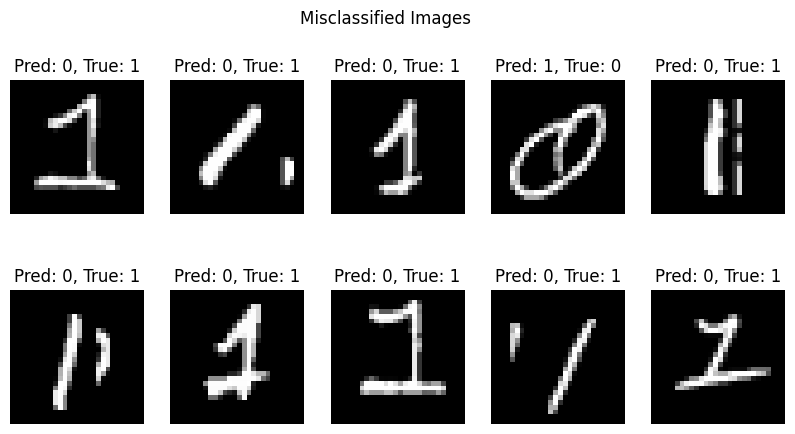

In [23]:
 #Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == Y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != Y)[0]

if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))

    for ax, idx in zip(axes.flat, misclassified_idx[:10]):  # Show 10 misclassified images
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {Y[idx]}")
        ax.axis("off")

    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

Question - 8:What does misclassified idx store, and how is it used in this code?
- Misclassified idx stores the indices of the images hwere pred_y and actual value(y) label is mismatched. It is used to find which images the model got wrong, display/visualize those misclassified images for analysis

Question - 9: How do you interpret the result if the output is ”All images were
correctly classified!”?
- It would mean every single images in the dataset had its predicted output (y_hat) equals to the actual value(label/y)..but mine results shows it has some of the misqualified images.

In [24]:
#4.4 Task 3: Perceptron Algorithm for 3 vs 5 Classification.
#4.5 To - Do: 1. Implement each Step as we implemented above.

df_2 = pd.read_csv("/content/drive/MyDrive/Ai workshop 1/mnist_3_and_5.csv")

In [26]:
X2 = df_2.drop(columns=["label"]).values
Y2 = df_2["label"].values
print("Feature matrix shape:", X2.shape)
print("Label vector shape:", Y2.shape)

Feature matrix shape: (2741, 784)
Label vector shape: (2741,)


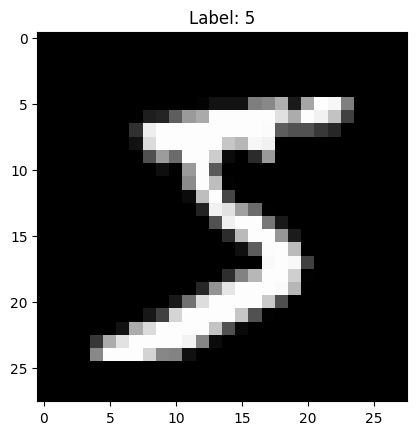

In [27]:
import numpy as np
import matplotlib.pyplot as plt


# Visualize first image
plt.imshow(X2[0].reshape(28,28), cmap='gray')
plt.title(f"Label: {Y2[0]}")
plt.show()

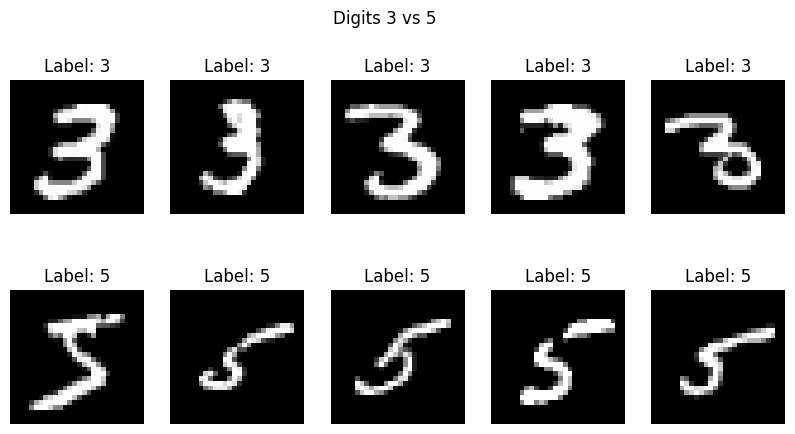

In [34]:
# Separate images for label 0 and label 1
images_3 = X2[Y2 == 3] # Get all images with label 0
images_5 = X2[Y2 == 5] # Get all images with label 1

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i in range(5):
    axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
    axes[0, i].set_title("Label: 3")
    axes[0, i].axis("off")

    axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
    axes[1, i].set_title("Label: 5")
    axes[1, i].axis("off")

plt.suptitle("Digits 3 vs 5")
plt.show()

Perceprtron works better with 0 and 1 so chnage value from 3,5

In [42]:
Y2 = np.where(Y2 == 3, 0, 1)  # 3 → 0, 5 → 1

In [43]:
def decision_function(X2, weights, bias):
    predictions = np.dot(X2, weights) + bias
    return np.where(predictions >= 0, 1, 0)


def train_perceptron(X2, Y2, weights, bias, learning_rate=0.1, epochs=100):

    for epoch in range(epochs):
        correct = 0

        for i in range(len(X2)):
            output = np.dot(X2[i], weights) + bias
            y_hat = 1 if output >= 0 else 0

            if y_hat == Y2[i]:
                correct += 1
            else:
                weights = weights + learning_rate * (Y2[i] - y_hat) * X2[i]
                bias = bias + learning_rate * (Y2[i] - y_hat)

        accuracy = correct / len(X2)

    return weights, bias, accuracy

In [44]:
weights, bias, accuracy = train_perceptron(X2, Y2, weights, bias)

print("Final Accuracy:", accuracy)

Final Accuracy: 0.45859175483400216


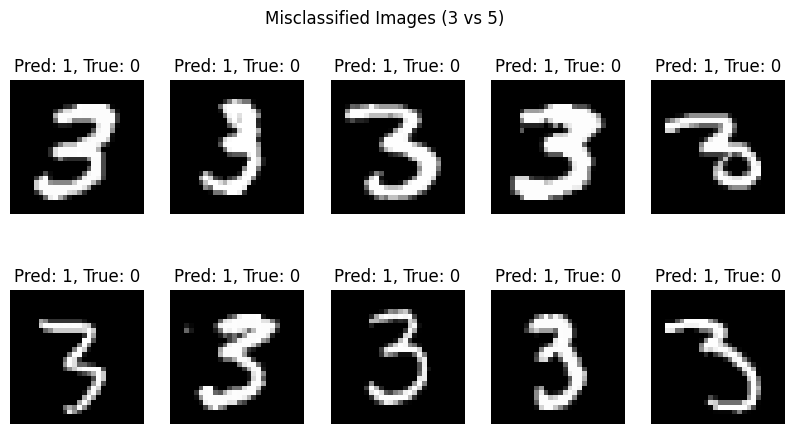

In [45]:
#misqualified images
predictions = np.dot(X2, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

misclassified_idx = np.where(y_pred != Y2)[0]

if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))

    for ax, idx in zip(axes.flat, misclassified_idx[:10]):
        ax.imshow(X2[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {Y2[idx]}")
        ax.axis("off")

    plt.suptitle("Misclassified Images (3 vs 5)")
    plt.show()
else:
    print("All images were correctly classified!")

Conclusion:

The perceptron model was successfully applied to classify digits 3 and 5.

Compared to 0 vs 1 classification, this task is more difficult because digits 3 and 5 are visually similar.

As a result, the model may produce some misclassifications.

This demonstrates the limitation of perceptron, as it can only handle linearly separable data.

For more complex patterns like 3 vs 5, more advanced models (e.g., multi-layer neural networks) are required.